## <p style="font-family:Arial; font-weight:normal; letter-spacing: 2px; color:#A52A2A; font-size:180%; text-align:center;padding: 0px; ">Advanced Techniques for transfer learning optimization</p>
#### Welcome to this Kaggle notebook! My objective is to identify plant species from images of dried and pressed plant specimens, which can be extremely useful for botanists, ecologists, and other researchers working with plants. The dataset used in this notebook consists of images of herbarium specimens from various plant species.
> We will use the fastai library and a pre-trained ResNet model as the basis for our image classifier. By leveraging transfer learning, we can take advantage of the knowledge acquired by the pre-trained model on a large dataset (e.g., ImageNet) and fine-tune it for our specific task.

## <p style="font-family:Arial; font-weight:normal; letter-spacing: 2px; color:#A52A2A; font-size:180%; text-align:center;padding: 0px; border-bottom: 1px solid #000000;">Data Preparation</p>
#### We will load the herbarium dataset's metadata from the JSON file, and extract the image paths and labels from it. The image paths are constructed based on the folder structure and image IDs. We will create a DataFrame with the image paths and labels, and then filter them to include only rows with existing image files.

#### Next, we'll define a DataBlock using the fastai library, which specifies the types of input (ImageBlock) and output (CategoryBlock), getter functions for the input and output, a random splitter for creating the training and validation sets, item and batch transformations. The DataBlock is used to create DataLoaders with a batch size of 64, which will be used for training and validating the image classification model.

In [ ]:
import fastbook
from fastbook import *
from fastai.vision.all import *
import json
from torchvision.models import resnet34
from fastai.vision.learner import cnn_learner
import os

#### Create DataFrame with the image_id, image_dir, category, and genus columns

In [ ]:
#train metadata json import
import json 
with open('herbarium-2022-fgvc9/train_metadata.json') as json_file:
    train_metadata = json.load(json_file)

train_dir = "herbarium-2022-fgvc9/train_images/"
image_ids = [image["image_id"] for image in train_metadata["images"]]
image_dirs = [train_dir + image['file_name'] for image in train_metadata["images"]]
category_ids = [annotation['category_id'] for annotation in train_metadata['annotations']]
genus_ids = [annotation['genus_id'] for annotation in train_metadata['annotations']]

df = pd.DataFrame({
    "image_id": image_ids,
    "image_path": image_dirs,
    "label": category_ids,
    "genus": genus_ids
})

#### Map the genus names to the genus column

In [ ]:
genus_map = {genus['genus_id']: genus['genus'] for genus in train_metadata['genera']}
df['name'] = df['genus'].map(genus_map)

#### For simplicity I will filter the DataFrame for the top 5 classes by size

In [ ]:
class_counts = df['name'].value_counts().nlargest(5).index
df = df[df['name'].isin(class_counts)]

#### Define a function to get the image files:

In [ ]:
def get_x(row):
    return row['image_path']

#### Define a function to get the labels:

In [ ]:
def get_y(row):
    return row['name']

#### Create a custom function that checks if the file exists before passing it to the DataBlock:

In [ ]:
def file_exists(path):
    return os.path.isfile(path)

#### Filter the DataFrame to include only rows with existing image files

In [ ]:
df = df[df['image_path'].apply(file_exists)]

#### Now, create a DataBlock. 
We apply the Resize(128) transformation which resizes each image to a square of size 128x128 pixels. Resizing is important to ensure that all images have the same dimensions when fed into the neural network. After, we apply two batch transformations: 
- `aug_transforms()` provides a set of default data augmentations, such as flipping, rotating, zooming, and changing the brightness and contrast.
- `Normalize.from_stats(*imagenet_stats)` normalizes the image data using the mean and standard deviation statistics of the ImageNet dataset

In [ ]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock(vocab=class_counts)),
    get_x=get_x,
    get_y=get_y,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(128),
    batch_tfms=[*aug_transforms(), Normalize.from_stats(*imagenet_stats)]
)

#### Create DataLoaders using the DataFrame:

In [ ]:
dls = dblock.dataloaders(df, bs=64)

#### It's important not to assume that our code works perfectly. When we create a DataBlock, if there's a mistake in the code, we'll see an error message. But if we don't see an error message that doesn't mean that it will work well. So, before training a model, we should always visualize our data. We can do this using the `show_batch` method.

In [ ]:
dls.show_batch(nrows=2, ncols=3)

#### Often, data scientists work with data with which they are not as familiar as domain experts may be: for instance, I actually don't know what a lot of these herbs are. Since I am not an expert on herbs, I can use Google images at this point to search for a few of these species, and make sure the images look similar to what I see in this output.

## <p style="font-family:Arial; font-weight:normal; letter-spacing: 2px; color:#A52A2A; font-size:180%; text-align:center;padding: 0px; border-bottom: 1px solid #000000;">Learning rate finder</p>
#### It's important to pick a good learning rate when training a model. If it's too low, the model will take a long time and many tries to learn. This wastes time and might cause the model to memorize the data, which isn't good.

#### You might wonder if setting the learning rate *really high* will help. Let's try it and see what happens:

In [ ]:
defaults.device = torch.device('cuda')
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1, base_lr=0.5)

#### The error rate increased, the result doesn't look promising. Here's the issue: the optimizer took a step in the right direction, but it went too far and overshot the lowest loss. Repeating this process only makes the optimizer drift further away, not closer.

#### So, how do we find the perfect learning rate that isn't too high or too low? In 2017 [Leslie Smith](https://arxiv.org/pdf/1506.01186.pdf), proposes a different approach to conventional wisdom on learning rates. Instead of using a single, constantly decreasing learning rate during training, the Cyclical Learning Rates (CLR) method suggests varying the learning rate within a range of values. This approach helps achieve near-optimal classification accuracy without the need to fine-tune the learning rate.

#### The CLR method is based on the observation that increasing the learning rate can have short-term negative effects but result in long-term benefits. By setting minimum and maximum boundaries, the learning rate changes cyclically between these limits. The paper found that various functional forms, such as triangular, Welch, and Hann windows, produced similar results. The triangular window was chosen for its simplicity.
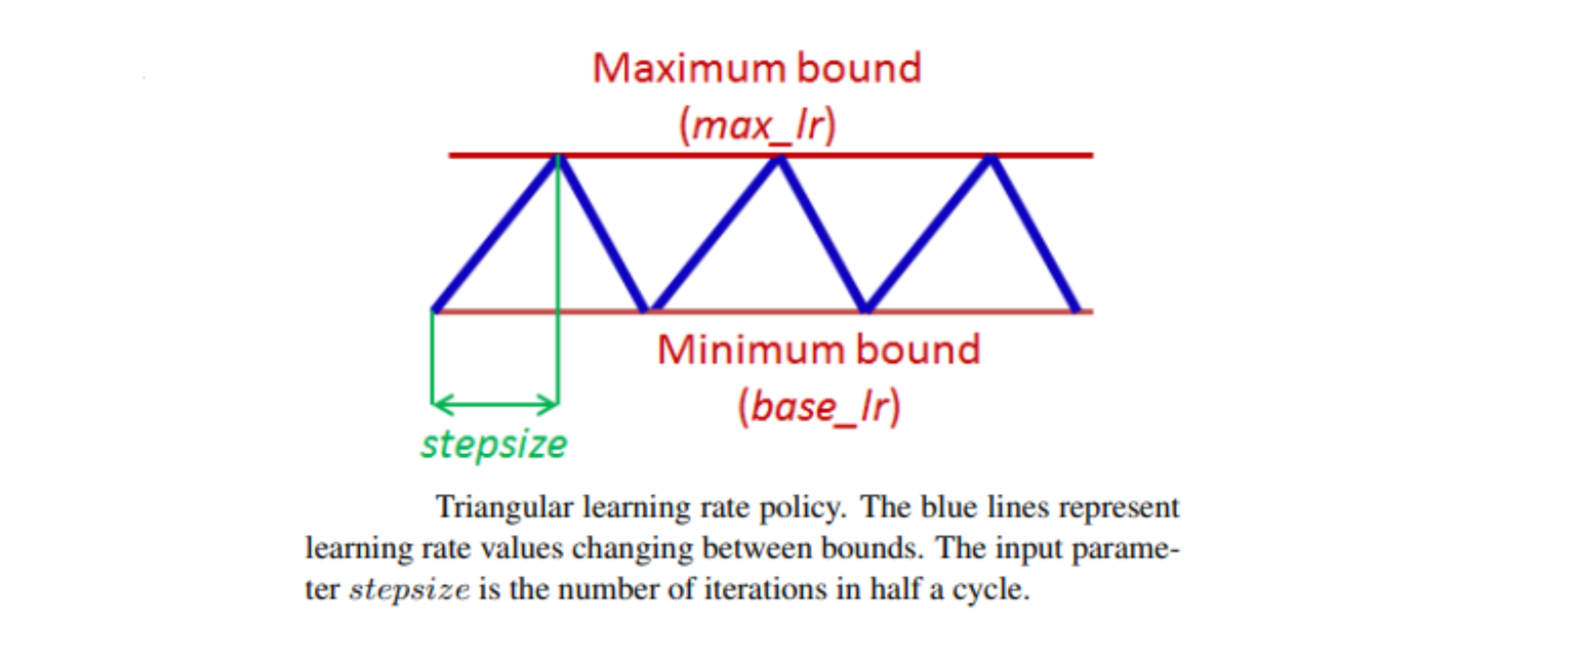

#### The idea is to start with an extremely small learning rate, so small that it's unlikely to be problematic. We use this for one mini-batch, check the losses, and then increase the learning rate by a certain percentage (like doubling it). After that, we perform another mini-batch, track the loss, and double the learning rate again. This process continues until the loss starts to worsen instead of improving. At this point, we know we've gone too far, so we choose a learning rate slightly lower than this.

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [ ]:
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")

#### We can see on this plot that in the range 1e-6 to 1e-4, nothing really happens and the model doesn't train. Then the loss starts to decrease until it reaches a minimum, and then increases again. We don't want a learning rate greater than 1e-1 as it will give a training that diverges like the one before (you can try for yourself), but 1e-1 is already too high: at this stage we've left the period where the loss was decreasing steadily.

#### In this learning rate plot it appears that a learning rate around 1e-3 would be appropriate, so let's choose that:

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2, base_lr=1e-3)

#### The result is way better than before! The learning rate finder, discovered in 2015, is a fascinating development, especially considering that neural networks have been studied since the 1950s. Finding a suitable learning rate has long been a critical and challenging task. The interesting part is that the solution doesn't need complex math, massive computing power, enormous datasets, or any other resource that might be out of reach for the average researcher. 
#### Leslie Smith, who came up with this idea, wasn't part of an elite Silicon Valley lab but worked as a naval researcher. This shows that breakthroughs in deep learning don't necessarily require extensive resources, elite teams, or advanced mathematical concepts. There's still plenty of work to be done, and all it takes is a bit of common sense, creativity, and persistence.

#### Now that we've found a good learning rate for our model, let's explore how to fine-tune the weights of a pretrained model.

## <p style="font-family:Arial; font-weight:normal; letter-spacing: 2px; color:#A52A2A; font-size:180%; text-align:center;padding: 0px; border-bottom: 1px solid #000000;">Unfreezing and Transfer Learning</p>

#### Transfer learning involves fine-tuning a pretrained model, which has already been trained on a massive dataset like ImageNet, for a different task. But what does that mean in practice?

#### A convolutional neural network is made up of multiple linear layers with nonlinear activation functions in between, ending with a final linear layer with an activation function like softmax. The last linear layer is designed to classify categories in the original dataset, so it's not useful when we apply transfer learning. Instead, we replace it with a new linear layer with the right number of outputs for our task (in our case 5).  

#### Although the new linear layer has random weights, the model isn't entirely random. The pretrained layers have already learned to be good at general image classification tasks. Early layers detect simple features like gradients and edges, while later layers recognize more complex patterns. By fine-tuning, we aim to retain these useful features from the pretrained model and adjust them as needed for our specific task, such as classifying vascular land plants.

#### Our goal with fine-tuning is to adjust the weights in the newly added linear layers to perform our specific task (classifying vascular land plants) without disrupting the pretrained weights in the other layers. To achieve this, we can use a simple technique called "freezing" the pretrained layers.

#### Fastai makes this process easy by automatically freezing all pretrained layers for us. When we called before the `fine_tune` method, it performed two steps:

#### 1. Train the new layers for one epoch while keeping the other layers frozen.
#### 2. Unfreeze all layers and train them for the requested number of epochs.
#### The second method, `fit_one_cycle` is a single-stage training method that trains the model for a given number of epochs using the one-cycle policy. The learning rate increases from a lower value to the specified learning rate, then decreases again. This method has shown to improve training efficiency and generalization in some cases.

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 1e-3)

#### In our case, the `fine_tune` method achieves a lower error rate, most likely because it leverages the pre-trained weights of the resnet34 architecture more effectively. The two-stage training process of `fine_tune` allows the model to adapt better to the specific problem at hand, resulting in better generalization and a lower error rate. On the other hand, the `fit_one_cycle` method might not be exploiting the pre-trained weights as effectively, leading to a higher error rate.

In [ ]:
# Unfreeze the model
learn.unfreeze()

#### Now we run `lr_find` again, because having more layers to train, and weights that have already been trained for three epochs, means our previously found learning rate isn't appropriate anymore:

In [ ]:
# Run lr_find again to find an appropriate learning rate
lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [ ]:
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")

#### Note that the graph is **very** different from when we had random weights: we don't have that sharp descent that indicates the model is training. That's because our model has been trained already. Here we have a somewhat flat area before a sharp increase, and we should take a point well before that sharp increase—for instance, 1e-5. The point with the maximum gradient isn't what we look for here and should be ignored.

#### Let's train at a suitable learning rate:

In [ ]:
# Train the entire model with the new learning rate
learn.fit_one_cycle(6, lr_max=1e-5)

#### Our model has improved! But we can still enhance it further by using discriminative learning rates. The idea is that the deeper layers of the pretrained model may not require as high a learning rate as the last layers.
## <p style="font-family:Arial; font-weight:normal; letter-spacing: 2px; color:#A52A2A; font-size:180%; text-align:center;padding: 0px; border-bottom: 1px solid #000000;">Discriminative Learning Rates</p>

#### Discriminative learning rates involve using lower learning rates for the profound layers and higher learning rates for the newly added layers. The reason is that more profound layers learn basic features like edges, which are useful for almost any task, while later layers learn more complex and task-specific concepts.

#### Fastai's default approach incorporates discriminative learning rates, allowing you to pass a Python slice object as a learning rate. The first value in the slice will be the learning rate for the earliest layer, and the second value will be for the final layer. The layers in between will have learning rates that are multiplicatively equidistant throughout that range. By using this technique, we can fine-tune our model more effectively.

#### This idea is proposed in the "Universal Language Model Fine-tuning for Text Classification" [paper](https://arxiv.org/pdf/1801.06146.pdf) to modify the regular stochastic gradient descent (SGD). The steps are as follows: 
- Split the model's parameters  $\theta$ into ${ \theta^1, \dots, \theta^L }$ where $\theta^l$ contains the parameters of the $l$-th layer and L is the number of layers.
- Obtain learning rates ${\eta^1, \dots, \eta^L }$, where $\eta^l$ is the learning rate of the $l$-th layer.
- The SGD update with discriminative fine-tuning becomes: $\theta^l_t = \theta^l_{t-1} - \eta^l \cdot \nabla_{\theta^l} J(\theta)$
To choose the learning rates, first select $\eta^L$ for the last layer by fine-tuning only that layer, and use $\eta^{l-1} = \eta^l$ for lower layers. 

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 1e-3)
learn.unfreeze()
learn.fit_one_cycle(6, lr_max=slice(1e-6,1e-4))

#### Now the fine-tuning is working great! Let's see a graph of the training and validation loss:

In [ ]:
learn.recorder.plot_loss()

#### As you can see, the training loss keeps getting better and better. But notice that eventually the validation loss improvement slows, and sometimes even gets worse! This is the point at which the model is starting to overfit. In particular, the model is becoming overconfident of its predictions. But this does not mean that it is getting less accurate, necessarily. Take a look at the table of training results per epoch, and you will often see that the accuracy continues improving, even as the validation loss gets worse. In the end what matters is your accuracy, or more generally your chosen metrics, not the loss. The loss is just the function we've given the computer to help us to optimize.

## <p style="font-family:Arial; font-weight:normal; letter-spacing: 2px; color:#A52A2A; font-size:180%; text-align:center;padding: 0px; border-bottom: 1px solid #000000;">Conclusion</p>
#### In this notebook  you learned some important practical tips for fitting a transfer learning model (learning rate finder, unfreezing, discriminative learning rates). Using these tools will help you to build more accurate image models, more quickly.